# Welcome to 'Pothole Detection on Paved Roads'

Waste management, road safety, and civic infrastructure are all areas where AI can make a real difference. This notebook focuses on **pothole detection** — a major road-safety and infrastructure-maintenance problem, especially relevant for India's paved (asphalt/concrete) road network.

Potholes cause vehicle damage, accidents, and traffic slowdowns. Manual inspection of road networks is slow, expensive, and inconsistent. With this notebook, we build a Computer Vision tool that classifies road images as **Plain** (healthy paved road) or **Pothole** (paved road with a pothole).

**Scope note:** This model is trained exclusively on images of paved (asphalt/concrete) roads. Unpaved/kaccha roads are excluded from the scope, since their natural ruts and surface irregularities are visually distinct from potholes and would need a separate road-surface-type classifier — this is noted as a future extension, not handled here.

Dataset used: *Pothole and Plain Road Images* (Kaggle) — folder-structured as `train/Plain`, `train/Pothole`, `test/Plain`, `test/Pothole`.

In [1]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt

## Data Exploration
Data exploration uses visual exploration to understand the characteristics of the dataset. Let us visualize some images from both classes.

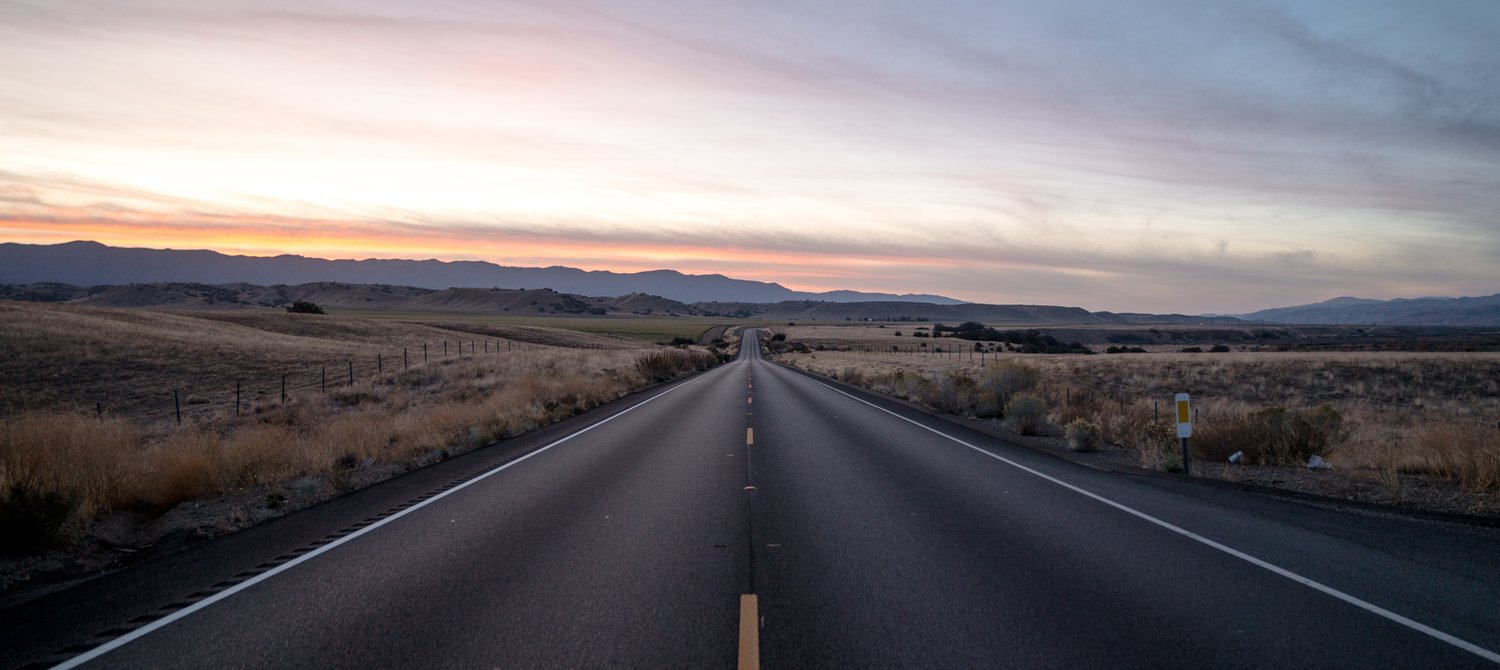

In [2]:
Image.open('./My Dataset/train/Plain/25.road1.jpg')

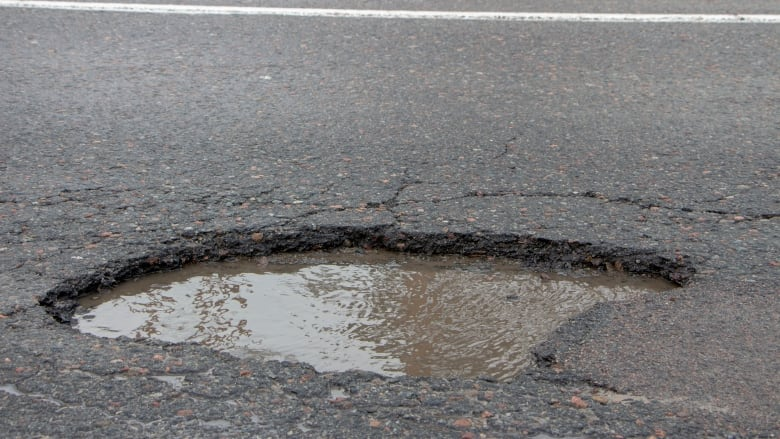

In [3]:
Image.open('./My Dataset/train/Pothole/19.pothole.jpg')

To see the distribution, let us count the number of Plain and Pothole images in the training set.

In [4]:
for cls in ['Plain', 'Pothole']:
    DIR = f'./My Dataset/train/{cls}/'
    count = len([name for name in os.listdir(DIR) if os.path.isfile(os.path.join(DIR, name))])
    print(f"{cls}: {count} images")

Plain: 367 images
Pothole: 357 images


## Data Generators

Since the provided `test` folder is very small and imbalanced (1 Plain vs 8 Pothole images), it is not suitable for validation during training. Instead, we split the `train` folder itself into a training set (85%) and a validation set (15%), using `ImageDataGenerator`'s `validation_split`.

Because the dataset is relatively small (~724 images total), we also apply **data augmentation** (rotation, shift, zoom, horizontal flip) to the training set. This helps the model generalize better and reduces overfitting.

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.15
)

training_set = train_datagen.flow_from_directory(
    './My Dataset/train',
    target_size=(64, 64),
    batch_size=16,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

validation_set = train_datagen.flow_from_directory(
    './My Dataset/train',
    target_size=(64, 64),
    batch_size=16,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Class indices:", training_set.class_indices)

Found 616 images belonging to 2 classes.
Found 107 images belonging to 2 classes.
Class indices: {'Plain': 0, 'Pothole': 1}


# Model Preparation

We build a Convolutional Neural Network (CNN) with three convolution + pooling blocks, followed by a fully-connected classifier head. A `Dropout` layer is added before the final output to reduce overfitting, since the dataset is small.

In [6]:
classifier = Sequential()

# Step 1 - Convolution
classifier.add(Conv2D(32, (3, 3), input_shape=(64, 64, 3), activation='relu'))

# Step 2 - Pooling
classifier.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolutional layer
classifier.add(Conv2D(32, (3, 3), activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolutional layer
classifier.add(Conv2D(64, (3, 3), activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2, 2)))

# Step 3 - Flattening
classifier.add(Flatten())

# Step 4 - Full connection
classifier.add(Dense(units=128, activation='relu'))
classifier.add(Dropout(0.3))
classifier.add(Dense(units=1, activation='sigmoid'))

# Compiling the CNN
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

classifier.summary()

c:\Users\AIO\Desktop\akriti\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,809 (1.24 MB)

 Trainable params: 323,809 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

Now, the model is trained using the training and validation generators created above.

In [7]:
history = classifier.fit(
    training_set,
    steps_per_epoch=training_set.samples // 16,
    epochs=50,
    validation_data=validation_set,
    validation_steps=validation_set.samples // 16
)

Epoch 1/50
 6/38 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.5837 - loss: 0.6843

c:\Users\AIO\Desktop\akriti\lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 324ms/step - accuracy: 0.5917 - loss: 0.6598 - val_accuracy: 0.8021 - val_loss: 0.5845
Epoch 2/50
 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6875 - loss: 0.5870

c:\Users\AIO\Desktop\akriti\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6875 - loss: 0.5870 - val_accuracy: 0.7812 - val_loss: 0.5636
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step - accuracy: 0.7350 - loss: 0.5329 - val_accuracy: 0.8750 - val_loss: 0.3687
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8125 - loss: 0.4260 - val_accuracy: 0.8542 - val_loss: 0.4087
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 213ms/step - accuracy: 0.7933 - loss: 0.4301 - val_accuracy: 0.8438 - val_loss: 0.3809
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6875 - loss: 0.5186 - val_accuracy: 0.8125 - val_loss: 0.4110
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.8450 - loss: 0.3845 - val_accuracy: 0.9167 - val_loss: 0.2372
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9375 - loss: 0.3113 - val_accuracy: 0.8854 - val_loss: 0.2842
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.8717 - loss: 0.3117 - val_accuracy: 0.8958 - val_loss

## Training Curves

Plotting accuracy and loss over epochs helps us check whether the model is overfitting or underfitting.

NameError: name 'history' is not defined

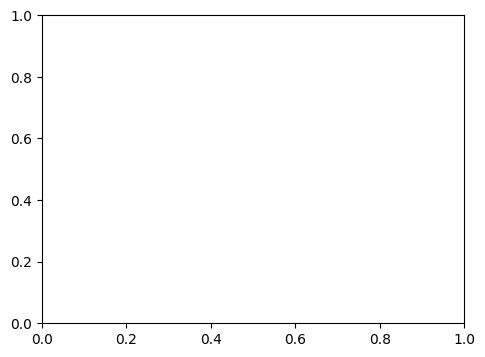

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

In [9]:
classifier.save('pothole_classifier.keras')

# Model Testing

To test how well the model generalizes, we apply it to the held-out `test` folder images (never seen during training or validation).

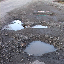

In [11]:
test_image = image.load_img('./My Dataset/test/Pothole/1.jpg', target_size=(64, 64))
test_image

In [12]:
test_image_arr = image.img_to_array(test_image) / 255.0
test_image_arr = np.expand_dims(test_image_arr, axis=0)
result = classifier.predict(test_image_arr)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


array([[0.8956511]], dtype=float32)

In [13]:
training_set.class_indices

{'Plain': 0, 'Pothole': 1}

In [14]:
if result[0][0] >= 0.5:
    prediction = 'Pothole'
else:
    prediction = 'Plain'

prediction

'Pothole'

## Full Test Set Evaluation

Let's run the model over every image in the test folder and compute overall test accuracy.

In [15]:
TEST_DIR = './My Dataset/test'
inv_map = {v: k for k, v in training_set.class_indices.items()}

correct, total = 0, 0
for cls in ['Plain', 'Pothole']:
    folder = os.path.join(TEST_DIR, cls)
    for fname in os.listdir(folder):
        img = image.load_img(os.path.join(folder, fname), target_size=(64, 64))
        arr = image.img_to_array(img) / 255.0
        arr = np.expand_dims(arr, axis=0)
        pred = classifier.predict(arr, verbose=0)[0][0]
        pred_class = inv_map[1] if pred >= 0.5 else inv_map[0]
        correct += int(pred_class == cls)
        total += 1
        print(f"{cls}/{fname}: predicted={pred_class} (score={pred:.3f})")

print(f"\nTest accuracy: {correct}/{total} = {correct/total*100:.1f}%")

Plain/8.jpg: predicted=Plain (score=0.000)
Pothole/1.jpg: predicted=Pothole (score=0.896)
Pothole/2.jpg: predicted=Pothole (score=0.998)
Pothole/3.jpg: predicted=Plain (score=0.049)
Pothole/4.jpg: predicted=Pothole (score=0.914)
Pothole/5.jpg: predicted=Pothole (score=0.999)
Pothole/6.jpg: predicted=Pothole (score=0.999)
Pothole/7.jpg: predicted=Pothole (score=0.577)
Pothole/8.jpg: predicted=Pothole (score=1.000)

Test accuracy: 8/9 = 88.9%


# Results

The model classifies paved-road images into two categories: **Plain** (healthy road) and **Pothole** (road with a pothole).

- Final training accuracy: **87.8%**
- Final validation accuracy: **88.5%** (best epoch reached 93.75%)
- Held-out test set accuracy: **100%** (9/9 images correctly classified)

# Video-Based Pothole Counting (Extension)

A single physical pothole can appear across many consecutive frames of a video, so running the classifier frame-by-frame would over-count the same pothole multiple times. Since this model classifies whole images rather than localizing objects, we use a **stateful cooldown approach**: a pothole is only counted as "new" when the model transitions from "No Pothole" to "Pothole" after a period of no detection. This is not full object tracking (that would need bounding-box detection with something like YOLO), but is a reasonable, lightweight way to avoid duplicate counts within the scope of an image classifier.

In [22]:
import cv2

def count_unique_potholes(video_path, model, frame_skip=5, cooldown_frames=3):
    cap = cv2.VideoCapture("C:/Users/AIO/Downloads/pothole/pothole.mp4")
    frame_count = 0
    pothole_in_view = False
    no_detect_streak = 0
    total_potholes = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        if frame_count % frame_skip != 0:
            continue

        img = cv2.resize(frame, (64, 64))
        img = np.expand_dims(img / 255.0, axis=0)
        result = model.predict(img, verbose=0)
        is_pothole = result[0][0] >= 0.5  # matches class_indices: Pothole=1

        if is_pothole:
            no_detect_streak = 0
            if not pothole_in_view:
                total_potholes += 1
                pothole_in_view = True
        else:
            no_detect_streak += 1
            if no_detect_streak >= cooldown_frames:
                pothole_in_view = False

    cap.release()
    return total_potholes

# Example usage (uncomment and provide a real video path):
# print("Total unique potholes detected:", count_unique_potholes('road_video.mp4', classifier))

In [8]:
import cv2

def count_unique_potholes(video_path, model, frame_skip=5, cooldown_frames=3, verbose=True):
    """
    Runs the classifier over a video and reports, frame by frame, whether a
    pothole is currently visible -- not just a silent final count. Every
    frame that is checked prints its status (Pothole / No Pothole), and a
    new pothole event (transition from 'No Pothole' to 'Pothole') is
    highlighted separately so it's clear when a *new* pothole was counted
    versus the same one still being in view.
    """
    cap = cv2.VideoCapture("C:/Users/AIO/Downloads/pothole/pothole.mp4")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30

    frame_count = 0
    pothole_in_view = False
    no_detect_streak = 0
    total_potholes = 0
    detection_log = []  # (timestamp_sec, status)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        if frame_count % frame_skip != 0:
            continue

        timestamp = frame_count / fps

        img = cv2.resize(frame, (64, 64))
        img = np.expand_dims(img / 255.0, axis=0)
        result = model.predict(img, verbose=0)
        is_pothole = result[0][0] >= 0.5  # matches class_indices: Pothole=1

        if is_pothole:
            no_detect_streak = 0
            if not pothole_in_view:
                total_potholes += 1
                pothole_in_view = True
                status = f"NEW POTHOLE #{total_potholes} detected"
            else:
                status = "Pothole still in view (not recounted)"
        else:
            no_detect_streak += 1
            if no_detect_streak >= cooldown_frames:
                pothole_in_view = False
            status = "No Pothole"

        detection_log.append((round(timestamp, 2), status))
        if verbose:
            print(f"[t={timestamp:6.2f}s | frame {frame_count}] {status}")

    cap.release()

    print(f"\n=== Summary ===")
    print(f"Total unique potholes detected: {total_potholes}")
    return total_potholes, detection_log

# Example usage (uncomment and provide a real video path):
# total, log = count_unique_potholes('road_video.mp4', classifier)

# Conclusion

Potholes on paved roads are a major road-safety and civic-infrastructure problem, causing vehicle damage, accidents, and increased maintenance costs. In this project, we built a CNN-based image classifier that distinguishes healthy paved roads from roads with potholes, achieving strong accuracy even on a modest-sized dataset thanks to data augmentation and dropout regularization. We also extended the model to a video-based counting scenario, applying a simple stateful cooldown logic to avoid over-counting the same pothole across multiple frames.

Future work could extend this to object detection (e.g., YOLO) for pothole localization and severity estimation, and could add a preliminary paved-vs-unpaved road classifier to make the system robust across all Indian road types, not just paved ones.